Name:   Srujana Duggineni

ID:     C00313483

## ASL Classification Using CNNs
[American Sign Language Dataset]


https://www.kaggle.com/datasets/ayuraj/asl-dataset

1. Business Understanding:
Objective:

The objective of this work is to classify ASL hand signs using deep learning architectures like a user-specified Convolutional Neural Network (CNN), ResNet50, and VGG16. The dataset consists of images representing different ASL signs, which are preprocessed and fed into deep learning architectures for classification.

The models are trained and tested to determine the most accurate architecture in terms of accuracy and loss measures. Transfer learning is applied using ResNet50 and VGG16 for improved classification accuracy. Comparison of the two models and their pros and cons in ASL recognition is what this work aims.

In [25]:
!pip -q install tensorflow
!pip -q install pydot
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import kagglehub
import zipfile
from tensorflow.keras.utils import plot_model
# Load the dataset
!unzip /content/sample_data/asl_dataset.zip -d /content/sample_data/
data_dir = "/content/sample_data/asl_dataset"


# Use the dataset

data_dir = '/content/sample_data/asl_dataset/'
batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

class_names = train_ds.class_names
print(class_names)




Archive:  /content/sample_data/asl_dataset.zip
replace /content/sample_data/asl_dataset/0/hand1_0_bot_seg_1_cropped.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/sample_data/asl_dataset/0/hand1_0_bot_seg_1_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_bot_seg_2_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_bot_seg_3_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_bot_seg_4_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_bot_seg_5_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_dif_seg_1_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_dif_seg_2_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_dif_seg_3_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_dif_seg_4_cropped.jpeg  
  inflating: /content/sample_data/asl_dataset/0/hand1_0_dif_seg_5_cropped.jpeg  
  inflating: /content/sample

#### 2.understanding Data
Dataset is made up of images that depict ASL signs, grouped into folders representing different classes.



Ground Truth Label: t


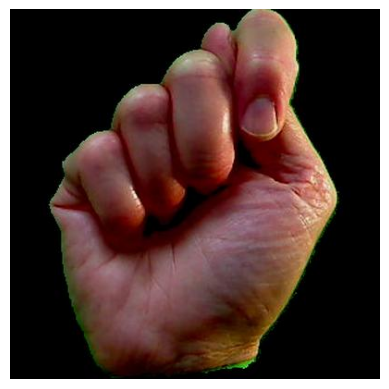



Ground Truth Label: c


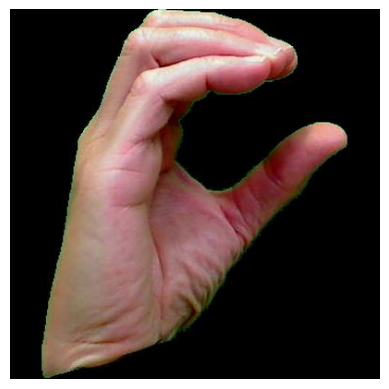



Ground Truth Label: y


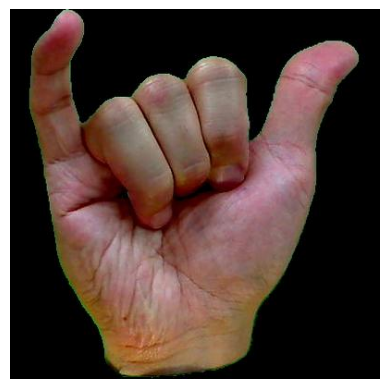



Ground Truth Label: f


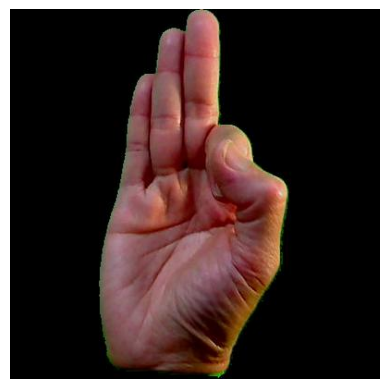



Ground Truth Label: k


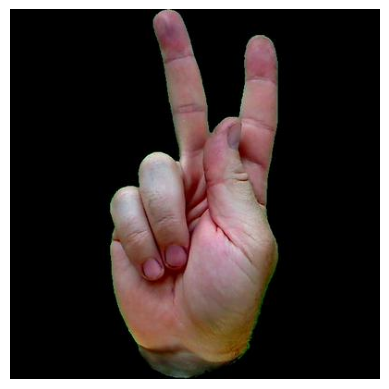

In [26]:
import random

image_count = len(list(pathlib.Path(data_dir).glob('*/*.jpeg')))

random_indices = random.sample(range(image_count),5)

for i in random_indices:
  image_path = list(pathlib.Path(data_dir).glob('*/*.jpeg'))[i]
  image = plt.imread(image_path)
  label = image_path.parent.name
  plt.imshow(image)
  print(f"\n\nGround Truth Label: {label}")

  plt.axis('off')
  plt.show()

In [27]:
#### the structure of the image batch
for images, labels in train_ds.take(1):
    print("Number of images:", images.shape[0])
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Label batch shape:", labels.shape)


Number of images: 32
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Label batch shape: (32,)


#### 3. Data Augementation
Random flipping, rotation, and brightness changes

In [28]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

#### 4.1 Building simple CNN Architecture and Visualize Architecture

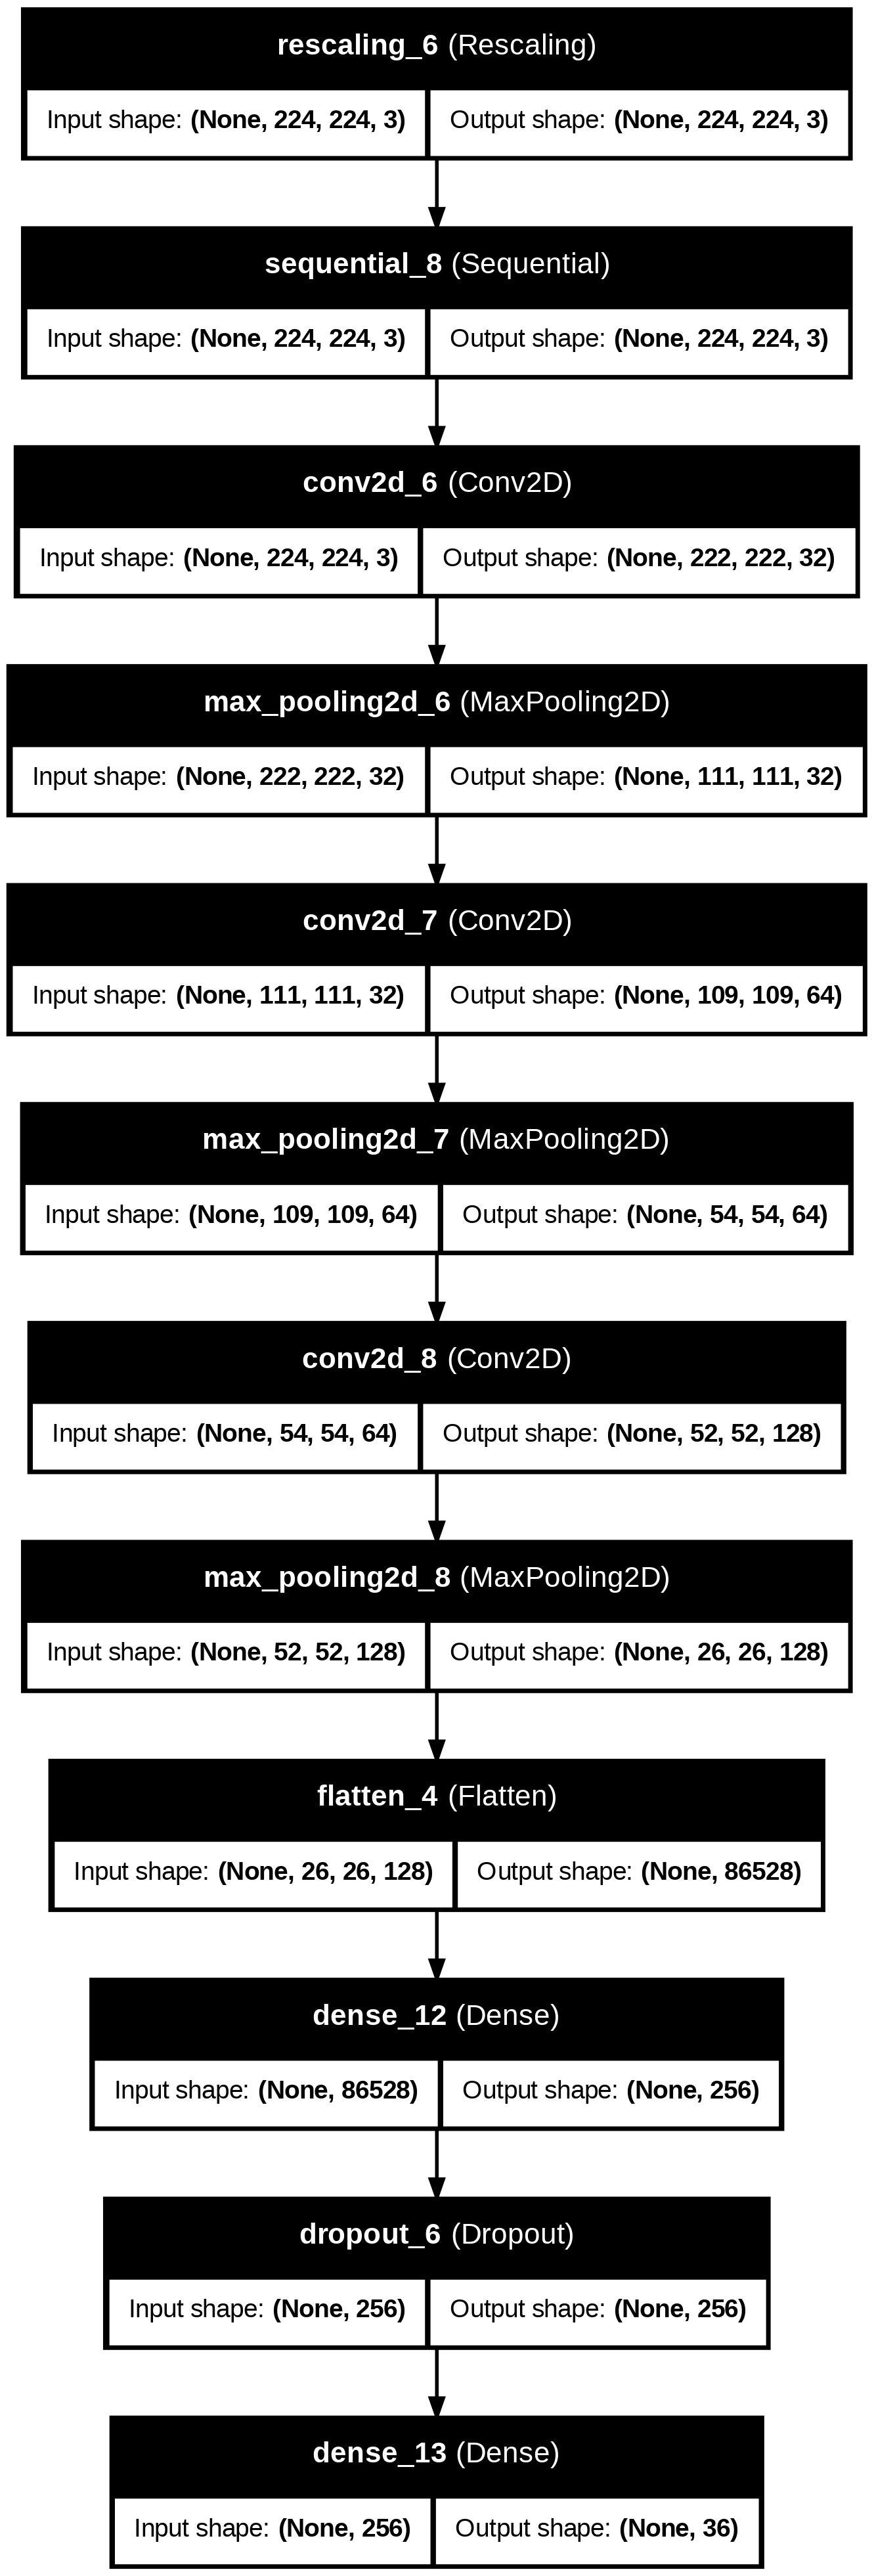

In [29]:
simple_cnn = keras.Sequential([
    layers.Rescaling(1./255),

    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(asl_data.class_names), activation='softmax')
])
simple_cnn.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
# Build the model before plotting
simple_cnn.build(input_shape=(None, 224, 224, 3))


plot_model(simple_cnn, to_file='simple_cnn.png', show_shapes=True, show_layer_names=True)

#### 4.2 Using resnet50 CNN Architecture and Visualize Architecture

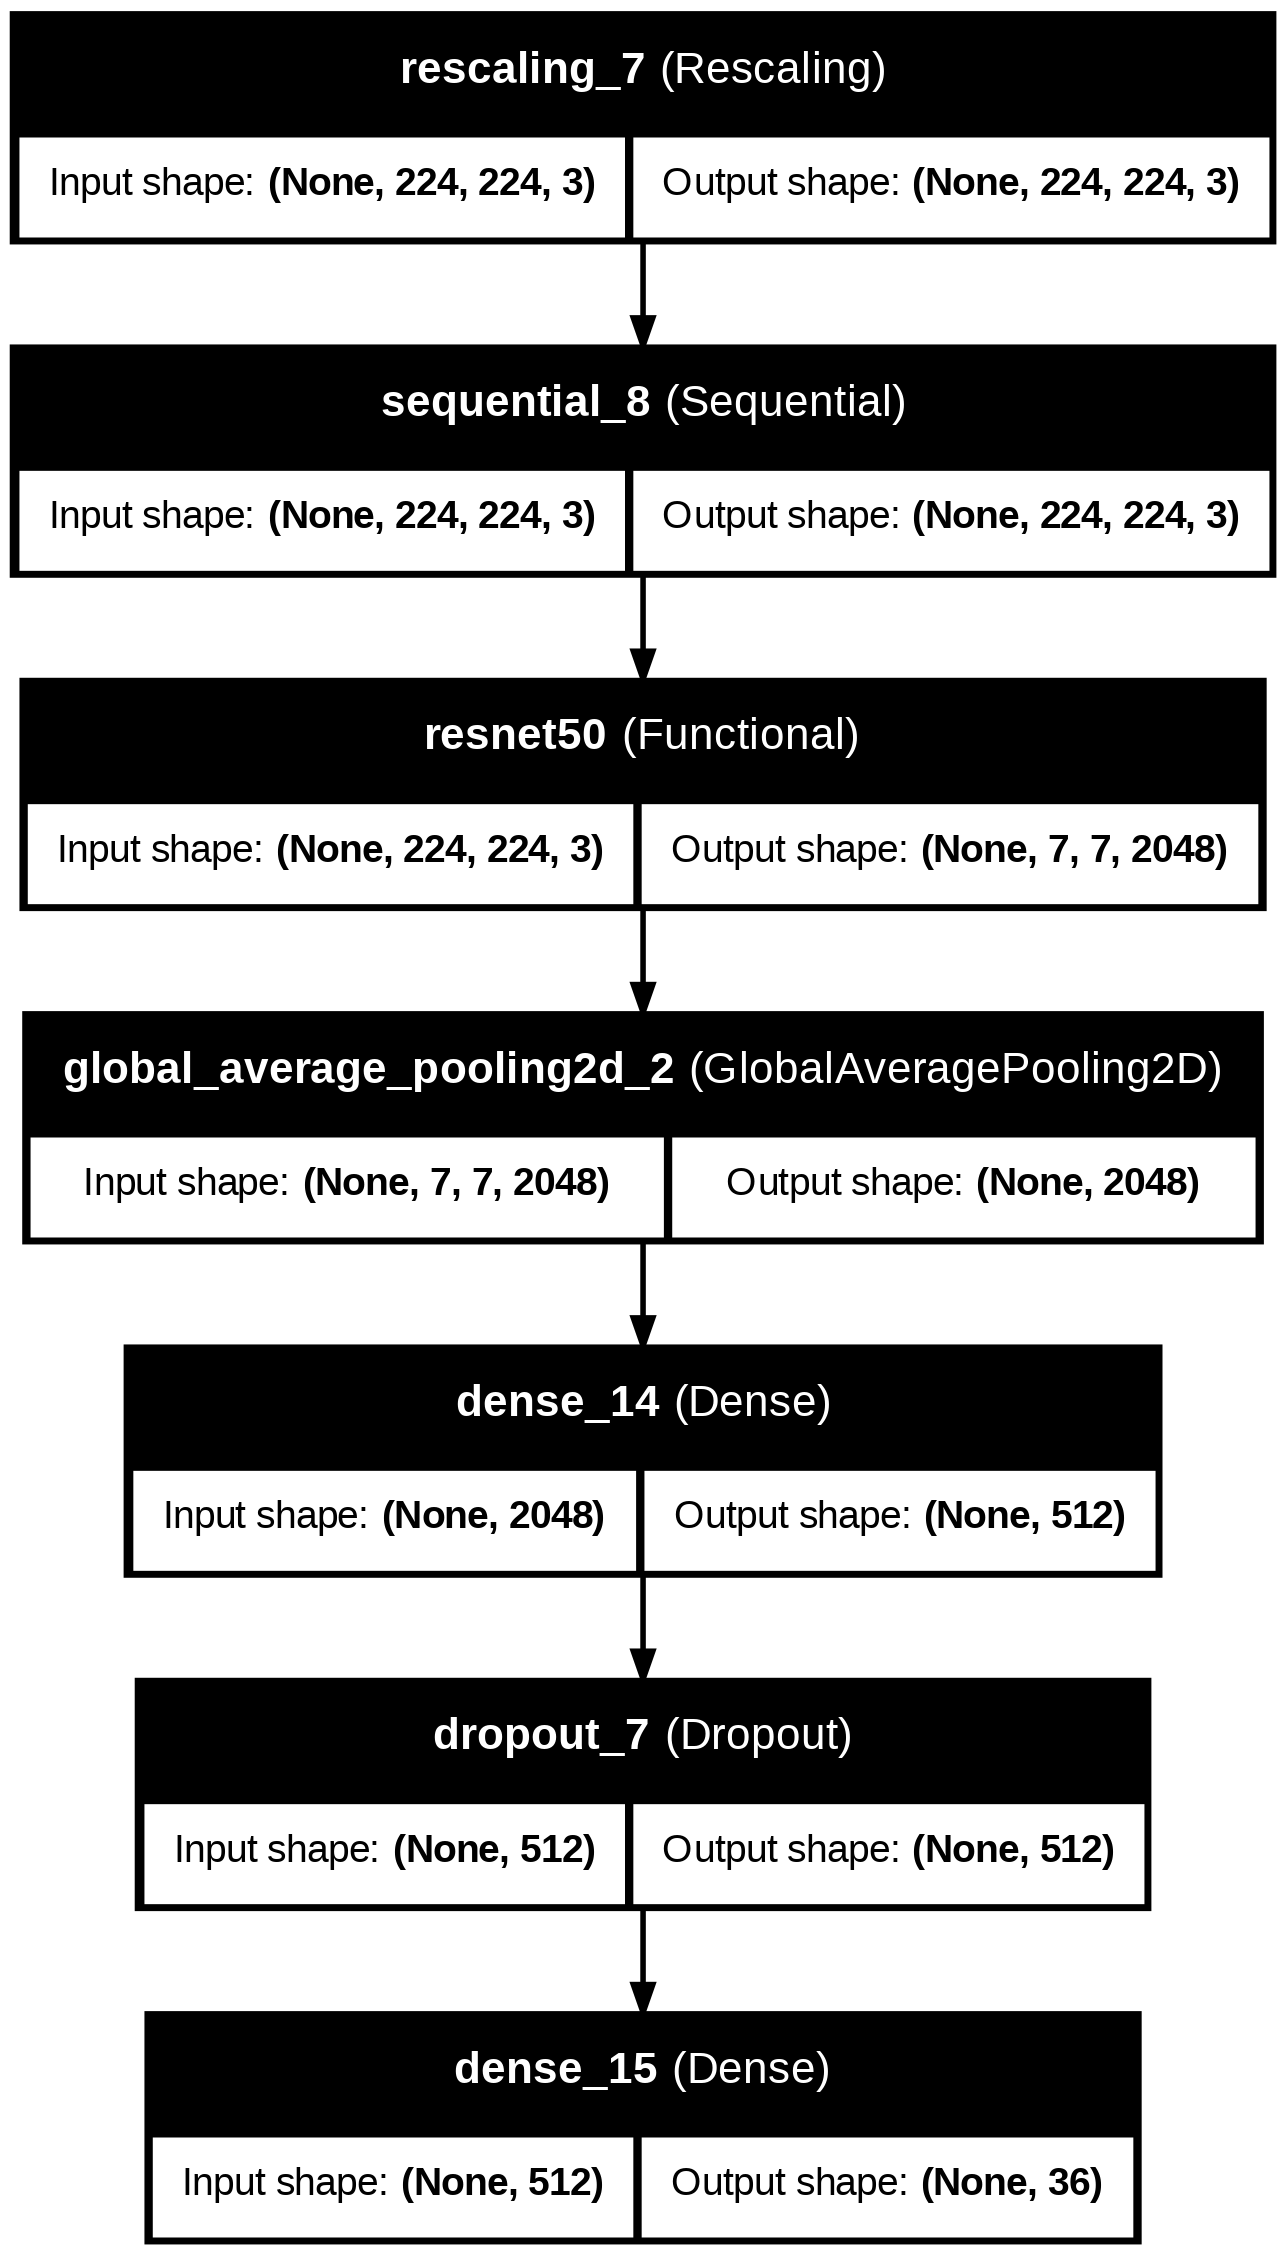

In [30]:
base_model_resnet = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_resnet.trainable = False
fine_tune_at = len(base_model_resnet.layers) // 2
for layer in base_model_resnet.layers[fine_tune_at:]:
    layer.trainable = True

resnet50 = keras.Sequential([
    layers.Rescaling(1./255),

    data_augmentation,
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(asl_data.class_names), activation='softmax')
])
resnet50.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Build the model before plotting
resnet50.build(input_shape=(None, 224, 224, 3))


plot_model(resnet50, to_file='resnet50.png', show_shapes=True, show_layer_names=True)

#### 4.3 Building VGG16 CNN Architecture and Visualize Architecture

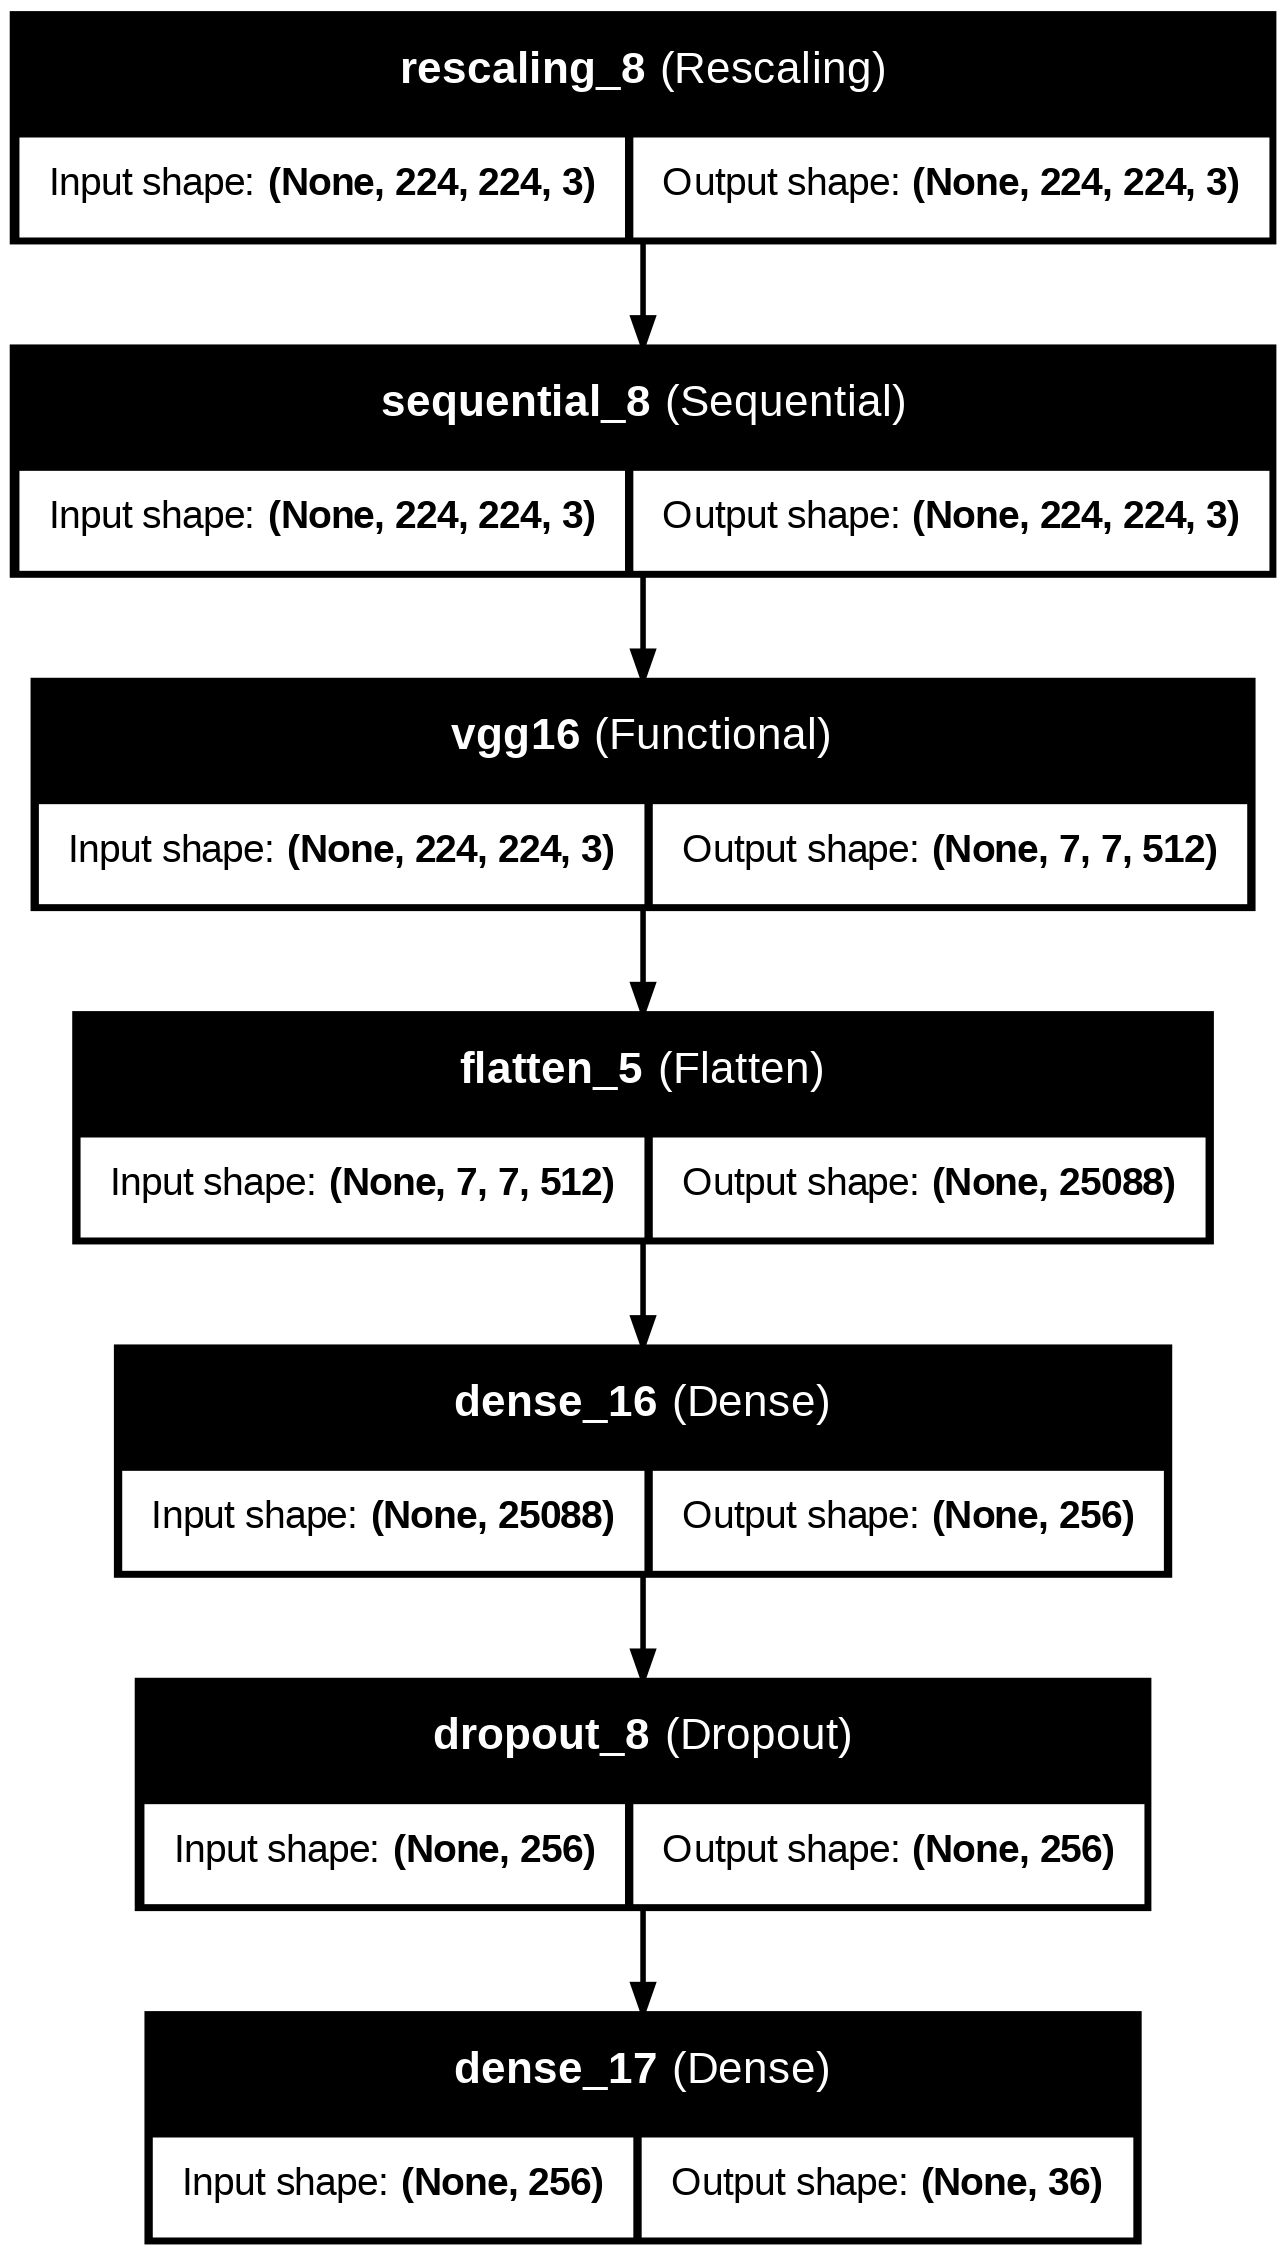

In [31]:

base_model_vgg = keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_vgg.trainable = False

vgg16 = keras.Sequential([
    layers.Rescaling(1./255),

    data_augmentation,
    base_model_vgg,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(asl_data.class_names), activation='softmax')
])
vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Build the model before plotting
vgg16.build(input_shape=(None, 224, 224, 3))


plot_model(vgg16, to_file='vgg16.png', show_shapes=True, show_layer_names=True)

#### 5. Model Evalution

In [32]:
models = {"ResNet50": resnet50, "Simple CNN": simple_cnn, "VGG16": vgg16}

histories = {}
for name, model in models.items():
    print(f"Training {name}... started")
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    histories[name] = model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stopping])
    print(f"Training {name}... done")

Training ResNet50... started
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 416ms/step - accuracy: 0.0679 - loss: 3.5382 - val_accuracy: 0.0298 - val_loss: 3.7006
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 306ms/step - accuracy: 0.2053 - loss: 2.5956 - val_accuracy: 0.0775 - val_loss: 4.6711
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 323ms/step - accuracy: 0.3542 - loss: 2.0256 - val_accuracy: 0.1750 - val_loss: 3.6095
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.4927 - loss: 1.5053 - val_accuracy: 0.4612 - val_loss: 1.6447
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.5509 - loss: 1.3722 - val_accuracy: 0.5249 - val_loss: 1.4213
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.6220 - loss: 1.1405 - val_accuracy: 0.6819 - val_loss: 0.9260
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.6738 - loss: 0.9499 - val_accuracy: 0.6998 - val_loss: 0.7872
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.7

#### 6. Performance visualization

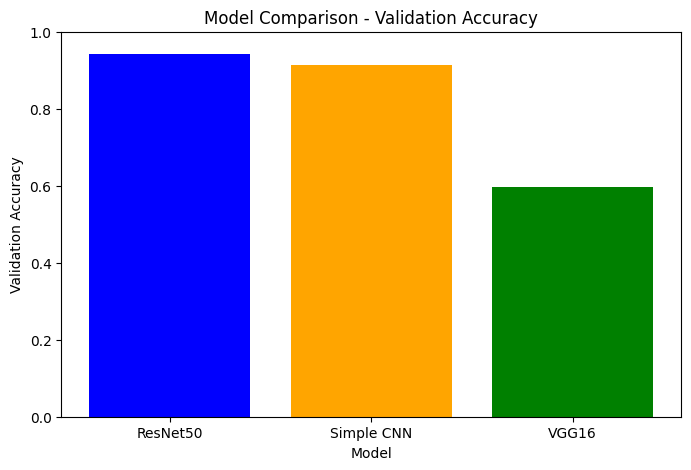

In [33]:
def plot_comparison(histories):
    accuracies = {name: max(hist.history['val_accuracy']) for name, hist in histories.items()}
    plt.figure(figsize=(8, 5))
    plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'orange', 'green'])
    plt.xlabel("Model")
    plt.ylabel("Validation Accuracy")
    plt.title("Model Comparison - Validation Accuracy")
    plt.ylim(0, 1)
    plt.show()

plot_comparison(histories)

##### observation
- ResNet50: Exhibits the highest validation accuracy, close to 95%.
- Simple CNN: Achieves a slightly lower validation accuracy, around 92%.
- VGG16: Shows significantly lower validation accuracy, around 60%.

#### 7.Conclusion
- ResNet50 is the Best Performing Model: In terms of validation accuracy, ResNet50 outperforms Simple CNN and VGG16. This shows that the ResNet50 model is suitable for the provided task and dataset.

- Simple CNN is a Viable Alternative: While not nearly as accurate as ResNet50, Simple CNN still achieves high validation accuracy. It is a good choice if computational resources are limited because it is likely a less complex model than ResNet50.

- VGG16 Does Not Do Well on the Task: VGG16 does significantly worse than the other two models. This indicates that VGG16 is not an appropriate architecture for this specific task or dataset.

***Implications for Model Selection***: When selecting a model to deploy, ResNet50 would be the first option considering its superior performance. However, if model size or computational cost is an important factor, Simple CNN would be an adequate trade-off.

**More Investigation**: The significant difference in performance of VGG16 compared to all the other models warrants more investigation. It could be beneficial to experiment with several different hyperparameters, data augmentation techniques, or transfer learning schemes for VGG16 in an attempt to boost its performance.